# Noise-floor jitter bands for dead features

A **dead** (pure-noise) feature's weight and Autostep gradient trace are stationary, with a jitter
amplitude set entirely by the learned step-size, the residual power, and the L1 coefficient:

$$s_i = \sqrt{\frac{\alpha_i \, \mathbb{E}[\delta^2]}{2}}, \qquad
  |w_i| \le s_i - \frac{\lambda}{\mathbb{E}[x_i^2]}, \qquad
  |h_i| \le \frac{s_i}{\sqrt{2}}$$

Each band is a **one-sigma** band, so if it is right the quantity's rms equals the band exactly and
it sits inside the band $2\Phi(1) - 1 = 68.3\%$ of the time. The algorithm has to build the bands
online, estimating $\mathbb{E}[\delta^2]$ with the `v` trace and $\mathbb{E}[x_i^2]$ with a second
trace on the same horizon; every table below therefore compares that **learned** band against the
**analytic** band built from the measured $\mathbb{E}[\delta^2]$ and the true $\mathbb{E}[x_i^2]$.

Three learners are measured in turn: **LMS**, **LMS + L1**, and **LMS + L1 + Autostep** -- with the
L1 learner also judged against the no-L1 bands, to see how much the $\lambda$ term matters. L1 enters
through the gradient ($\lambda \, \mathrm{sign}(w)$ added to $\delta x$) so that Autostep's step-size
adaptation sees it too.

**Setup.** One seed, one `FeatureSiftingTask` supplying the target $y$, and a bank of `N_FEATURES`
*independent single-input learners*: learner $i$ owns one pure-noise feature $x_i \sim
\mathcal{N}(\mu_i, \sigma_i^2)$ (a different distribution per feature) and predicts $y$ from it
alone, so $\delta_i = w_i x_i - y$. Every feature is a dead feature by construction, and 10k of them
give the statistics cheaply. Pruning is deliberately **disabled** — the point is to measure the
un-pruned jitter the bands are meant to describe.

In [1]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import matplotlib.pyplot as plt
from scipy.stats import norm

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.optimizers.idbd import optax_idbd
from phd.jax_core.utils import tree_replace

In [2]:
# Task configuration (the task only supplies the target y here).
N_TARGET_FEATURES = 10
N_LEARNER_FEATURES = 20
TARGET_NOISE_STD = 1.0
NO_PRUNE = jnp.zeros(N_LEARNER_FEATURES, dtype=bool)

# Probe configuration.
N_FEATURES = 10_000     # independent single-feature learners, each on a pure-noise feature
N_BURN_IN = 40_000      # steps discarded so w, h and the traces reach their stationary distributions
N_SNAPSHOTS = 250       # snapshots kept for the statistics
RECORD_EVERY = 4_000    # steps between snapshots -- all features share one y sequence, so
                        # snapshots must be spread out to average over its slow common drift
BASE_SEED = 0

# Algorithm hyperparameters.
LEARNING_RATE = 2.0 ** -8
META_LEARNING_RATE = 2.0 ** -6
L1_COEFF = 0.01        # large enough to move the w band, small enough to keep it positive
K_V = 5.0               # both traces average over ~K_V of the learner's own adaptation timescales

PCT_OUTSIDE_1SIGMA = 100.0 * 2.0 * norm.sf(1.0)   # 31.7%: what a correct one-sigma band leaves out

## Features, bands and learner

Each feature gets its own mean and standard deviation, so the bank spans a wide range of
$\mathbb{E}[x_i^2]$ — which the $s_i$ term says should cancel out of the band, and the L1 term says
should not.

In [3]:
def sample_feature_dists(key):
    """Per-feature noise distributions: mean ~ U[-1, 1], std ~ log-uniform[0.1, 3]."""
    mu_key, sigma_key = jax.random.split(key)
    mu = jax.random.uniform(mu_key, (N_FEATURES, 1), minval=-1.0, maxval=1.0)
    log_sigma = jax.random.uniform(sigma_key, (N_FEATURES, 1),
                                   minval=jnp.log(0.1), maxval=jnp.log(3.0))
    return mu, jnp.exp(log_sigma)


def jitter_bands(step_size, delta2, x2, l1_coeff):
    """One-sigma jitter bands for a dead feature, from estimates of E[delta^2] and E[x^2].
    Called with the learner's traces online, and with the measured truth for comparison."""
    s = (step_size * delta2 / 2.0) ** 0.5
    return s - l1_coeff / x2, s / 2.0 ** 0.5      # (w band, h band)

In [4]:
class NoiseFloorProbe(eqx.Module):
    """A bank of `N_FEATURES` independent single-input linear learners sharing one target.

    Weights are shaped `(N_FEATURES, 1)`, so every per-feature quantity the optimizer computes --
    including Autostep's effective-step-size normaliser, which reduces over the last axis -- is
    computed per learner. `autostep=False` gives plain LMS (a fixed step-size, `meta_lr=0`) while
    still maintaining the IDBD gradient trace `h`, so the same bands can be evaluated."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    l1_coeff: float = eqx.field(static=True)
    w: jax.Array          # (N_FEATURES, 1)
    opt_state: optax.OptState
    v: jax.Array          # (N_FEATURES, 1) trace of delta^2
    x2: jax.Array         # (N_FEATURES, 1) trace of x^2, same horizon as v

    @classmethod
    def init(cls, l1_coeff=0.0, autostep=False):
        optimizer = optax_idbd(init_lr=LEARNING_RATE,
                               meta_lr=META_LEARNING_RATE if autostep else 0.0,
                               autostep=autostep)
        w = jnp.zeros((N_FEATURES, 1))
        return cls(optimizer=optimizer, l1_coeff=l1_coeff, w=w, opt_state=optimizer.init(w),
                   v=jnp.zeros((N_FEATURES, 1)), x2=jnp.zeros((N_FEATURES, 1)))

    def step(self, x, y):
        error = self.w * x - y                            # delta_i, one residual per learner
        loss = error ** 2
        loss_grads = error * x + self.l1_coeff * jnp.sign(self.w)   # L1 inside the gradient

        updates, opt_state = self.optimizer.update((loss_grads, x), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        step_size = jnp.exp(opt_state.beta)
        gain = step_size * x ** 2 / K_V                   # shared horizon for both traces
        v = self.v + gain * (loss - self.v)
        x2 = self.x2 + gain * (x ** 2 - self.x2)

        snapshot = dict(w=w, h=opt_state.h, v=v, x2=x2, loss=loss, step_size=step_size)
        return tree_replace(self, w=w, opt_state=opt_state, v=v, x2=x2), snapshot

In [5]:
def run(l1_coeff=0.0, autostep=False, seed=BASE_SEED):
    """Burn in, then take `N_SNAPSHOTS` snapshots `RECORD_EVERY` steps apart. Returns flat numpy
    arrays of every recorded per-feature quantity, plus the analytic bands built from the truth."""
    task_key, feature_key, noise_key = jax.random.split(jax.random.PRNGKey(seed), 3)
    task = FeatureSiftingTask(N_TARGET_FEATURES, N_LEARNER_FEATURES, TARGET_NOISE_STD, key=task_key)
    mu, sigma = sample_feature_dists(feature_key)
    state = NoiseFloorProbe.init(l1_coeff, autostep)

    def learn_step(carry, _):
        task, state, key = carry
        key, x_key = jax.random.split(key)
        task, (_, y) = task.step(NO_PRUNE)     # only the target is used; the task's own features are not
        x = mu + sigma * jax.random.normal(x_key, (N_FEATURES, 1))
        state, snapshot = state.step(x, y)
        return (task, state, key), snapshot

    def advance(carry, n_steps):               # run `n_steps` without keeping the snapshots
        carry, _ = jax.lax.scan(lambda c, _: (learn_step(c, None)[0], None), carry, length=n_steps)
        return carry

    @eqx.filter_jit
    def go():
        carry = advance((task, state, noise_key), N_BURN_IN)
        _, snapshots = jax.lax.scan(lambda c, _: learn_step(advance(c, RECORD_EVERY - 1), None),
                                    carry, length=N_SNAPSHOTS)
        return snapshots

    rec = jax.tree.map(lambda a: np.asarray(a).ravel(), go())
    rec['x2_true'] = np.tile(np.asarray(mu ** 2 + sigma ** 2).ravel(), N_SNAPSHOTS)
    return with_bands(rec, l1_coeff)


def with_bands(rec, l1_coeff):
    """Attach the bands for a given lambda to an existing run -- everything they need was recorded.
    Lets an L1 learner be re-judged against the bands of a different (e.g. zero) coefficient."""
    rec = dict(rec)
    rec['band_w'], rec['band_h'] = jitter_bands(rec['step_size'], rec['v'], rec['x2'], l1_coeff)
    rec['band_w_true'], rec['band_h_true'] = jitter_bands(
        rec['step_size'], rec['loss'].mean(), rec['x2_true'], l1_coeff)
    return rec

## Statistics

Two things are being checked for each of $w$ and $h$:

- **is the band right?** `% outside analytic band` should equal the 31.7% a correct one-sigma band
  leaves out.
- **does the learner recover it?** `% outside learned band` should match too, and
  `learned / analytic band` should be 1 — it drifts when the `v` or $x^2$ trace is a biased estimate
  of what it stands in for. The ratio is reported as a median because a band close to zero makes the
  mean explode.

A large enough $\lambda$ drives $s_i - \lambda / \mathbb{E}[x_i^2]$ negative for the weakest
features: L1 alone pins those weights at zero, so they have no band to test and are excluded.

In [6]:
def summarize(rec):
    ok = rec['band_w_true'] > 0        # L1 alone pins these at zero -- no band to test
    delta2 = rec['loss'].mean()
    out = {'E[delta^2]': delta2,
           'mean(v) / E[delta^2]': (rec['v'] / delta2).mean(),
           'mean(x2 trace) / E[x^2]': (rec['x2'] / rec['x2_true']).mean(),
           '% excluded (band <= 0)': 100.0 * (~ok).mean(),
           'target % outside band': PCT_OUTSIDE_1SIGMA}
    for name in ('w', 'h'):
        arr, band, band_true = rec[name][ok], rec[f'band_{name}'][ok], rec[f'band_{name}_true'][ok]
        out[f'{name}: % outside learned band'] = 100.0 * (np.abs(arr) > band).mean()
        out[f'{name}: % outside analytic band'] = 100.0 * (np.abs(arr) > band_true).mean()
        out[f'{name}: learned / analytic band'] = np.median(band / band_true)
    return {k: float(val) for k, val in out.items()}


def table(runs):
    return pd.DataFrame({label: summarize(rec) for label, rec in runs.items()}).round(3)

In [7]:
def plot_distributions(rec, label):
    """Distributions of the v trace and of h, then w and h each divided by its own band. If the
    bands really are one sigma, both rescaled distributions must be standard normal."""
    ok = rec['band_w_true'] > 0
    delta2 = rec['loss'].mean()

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

    axes[0].hist(rec['v'], bins=200, color='C0')
    axes[0].axvline(delta2, color='k', ls='--', label=f'E[$\\delta^2$] = {delta2:.2f}')
    axes[0].set(xlabel='v', ylabel='count', title='v (residual-power trace)')
    axes[0].legend()

    axes[1].hist(rec['h'], bins=200, range=np.quantile(rec['h'], [0.001, 0.999]), color='C1')
    axes[1].set(xlabel='h', title='h (gradient trace)')

    bins = np.linspace(-3, 3, 200)
    axes[2].hist(rec['w'][ok] / rec['band_w'][ok], bins=bins, histtype='step', density=True,
                 color='C2', label='$w_i$ / its band')
    axes[2].hist(rec['h'][ok] / rec['band_h'][ok], bins=bins, histtype='step', density=True,
                 color='C1', label='$h_i$ / its band')
    axes[2].plot(bins, norm.pdf(bins), 'k:', label='$\\mathcal{N}(0, 1)$: band = 1$\\sigma$')
    for edge in (-1, 1):
        axes[2].axvline(edge, color='k', ls='--', lw=1)
    axes[2].set(xlabel='multiples of the band (dashed = the band itself)',
                title='each quantity divided by its own band')
    axes[2].legend(loc='upper left', fontsize=8)

    fig.suptitle(label)
    fig.tight_layout()
    plt.show()

## 1. LMS

No regularisation, so the w band is just $s_i$ and neither band depends on $\mathbb{E}[x_i^2]$.

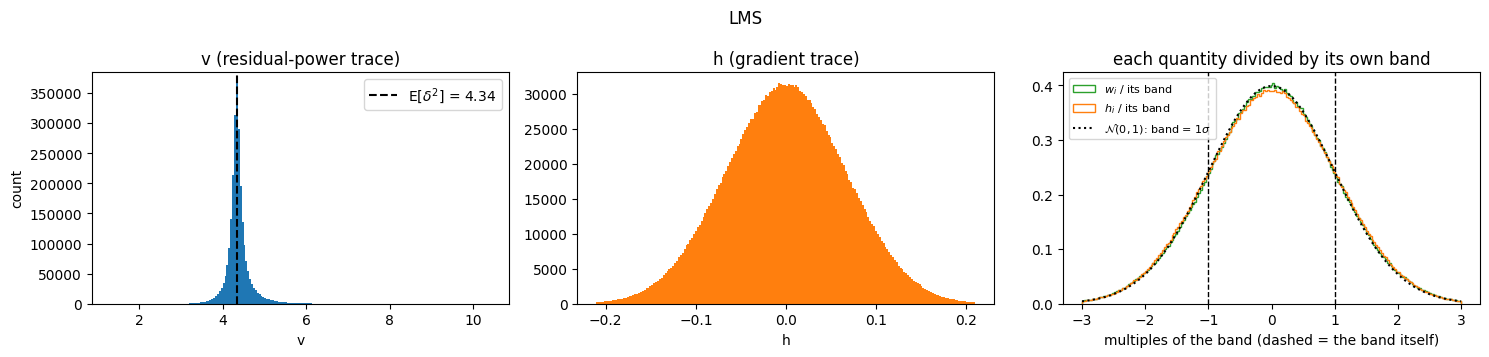

,LMS
E[delta^2],4.344
mean(v) / E[delta^2],1.005
mean(x2 trace) / E[x^2],2.388
% excluded (band <= 0),0.000
target % outside band,31.731
w: % outside learned band,32.331
w: % outside analytic band,32.398
w: learned / analytic band,0.999
h: % outside learned band,33.103
h: % outside analytic band,33.169


In [8]:
lms = run()
plot_distributions(lms, 'LMS')
table({'LMS': lms})

## 2. LMS + L1, judged by the no-L1 bands

$\lambda \, \mathrm{sign}(w)$ joins the gradient, but the bands are left as they were in section 1
($\text{band}_w = s_i$) — how wrong is it to ignore L1 when bounding the jitter? This is the same
run as section 3, only re-judged, and $\text{band}_h$ does not depend on $\lambda$ at all, so the
h rows differ from section 3 only through which samples are excluded.

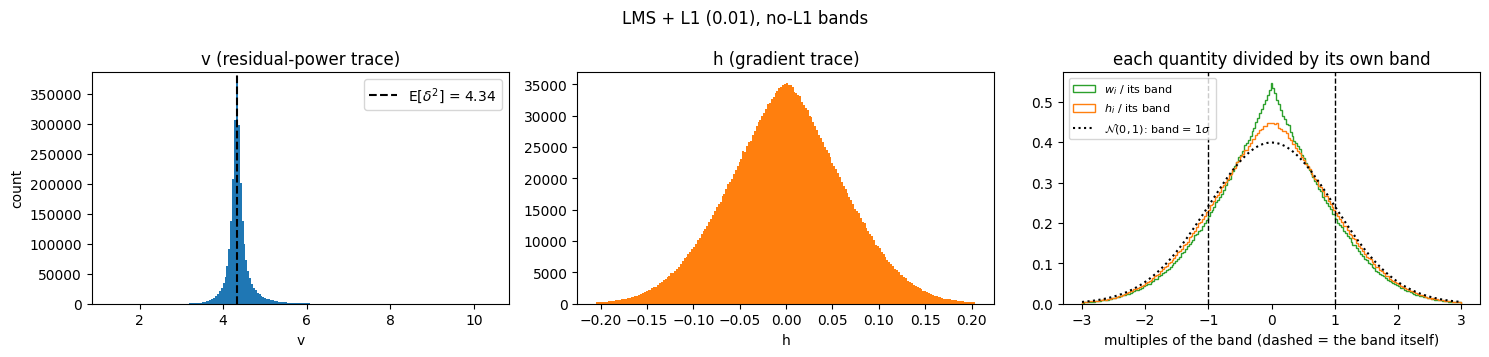

,"LMS + L1, no-L1 bands"
E[delta^2],4.343
mean(v) / E[delta^2],1.004
mean(x2 trace) / E[x^2],2.388
% excluded (band <= 0),0.000
target % outside band,31.731
w: % outside learned band,26.624
w: % outside analytic band,26.715
w: learned / analytic band,0.999
h: % outside learned band,29.491
h: % outside analytic band,29.576


In [9]:
lms_l1 = run(l1_coeff=L1_COEFF)
lms_l1_no_l1_bands = with_bands(lms_l1, 0.0)
plot_distributions(lms_l1_no_l1_bands, f'LMS + L1 ({L1_COEFF}), no-L1 bands')
table({'LMS + L1, no-L1 bands': lms_l1_no_l1_bands})

## 3. LMS + L1

The w band now shrinks by $\lambda / \mathbb{E}[x_i^2]$ — the one place a feature's own input scale
enters.

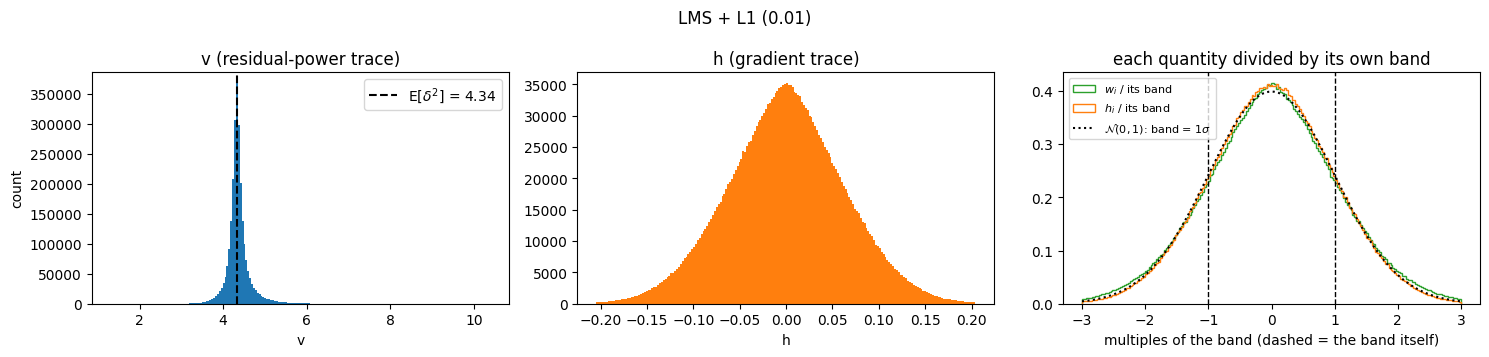

,LMS + L1
E[delta^2],4.343
mean(v) / E[delta^2],1.004
mean(x2 trace) / E[x^2],2.388
% excluded (band <= 0),8.460
target % outside band,31.731
w: % outside learned band,33.355
w: % outside analytic band,39.438
w: learned / analytic band,1.069
h: % outside learned band,31.142
h: % outside analytic band,31.247


In [10]:
plot_distributions(lms_l1, f'LMS + L1 ({L1_COEFF})')
table({'LMS + L1': lms_l1})

## 4. LMS + L1 + Autostep

Same equations, but each feature now learns its own $\alpha_i$, so $s_i$ moves with it.

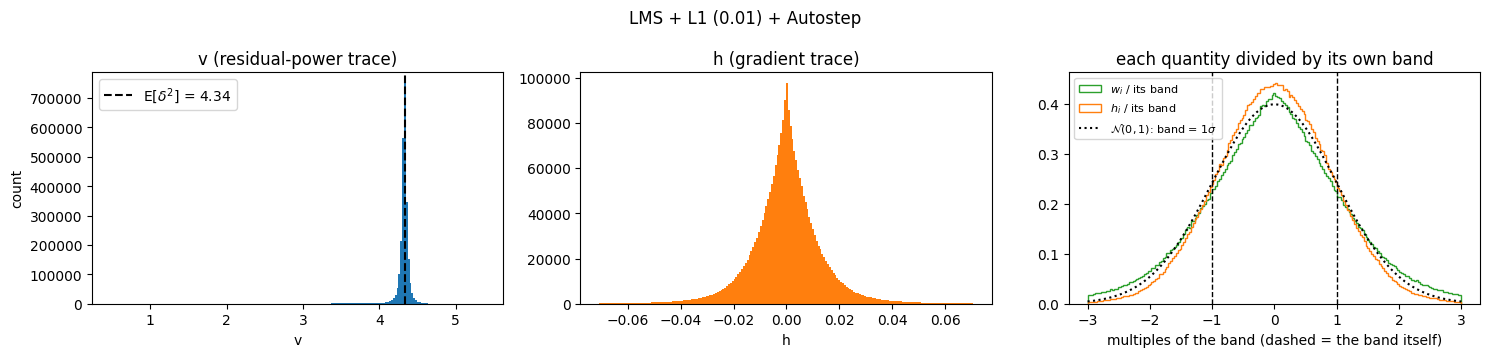

,LMS + L1 + Autostep
E[delta^2],4.337
mean(v) / E[delta^2],0.991
mean(x2 trace) / E[x^2],2.368
% excluded (band <= 0),35.036
target % outside band,31.731
w: % outside learned band,36.239
w: % outside analytic band,51.941
w: learned / analytic band,1.306
h: % outside learned band,27.513
h: % outside analytic band,27.495


In [11]:
autostep_l1 = run(l1_coeff=L1_COEFF, autostep=True)
plot_distributions(autostep_l1, f'LMS + L1 ({L1_COEFF}) + Autostep')
table({'LMS + L1 + Autostep': autostep_l1})

## Comparison

In [12]:
table({'LMS': lms, 'LMS + L1, no-L1 bands': lms_l1_no_l1_bands,
       'LMS + L1': lms_l1, 'LMS + L1 + Autostep': autostep_l1})

,LMS,"LMS + L1, no-L1 bands",LMS + L1,LMS + L1 + Autostep
E[delta^2],4.344,4.343,4.343,4.337
mean(v) / E[delta^2],1.005,1.004,1.004,0.991
mean(x2 trace) / E[x^2],2.388,2.388,2.388,2.368
% excluded (band <= 0),0.000,0.000,8.460,35.036
target % outside band,31.731,31.731,31.731,31.731
w: % outside learned band,32.331,26.624,33.355,36.239
w: % outside analytic band,32.398,26.715,39.438,51.941
w: learned / analytic band,0.999,0.999,1.069,1.306
h: % outside learned band,33.103,29.491,31.142,27.513
h: % outside analytic band,33.169,29.576,31.247,27.495


In [13]:
# Next I want to try if not all the feature generated are useful, and some percent of them are genuinely useless, what then?
# We don't want to keep the same feature forever. Does the arming mechanism make a difference then?

## 5. A pruning rule from the bands

The bands describe what a *useless* feature looks like, so a pruning rule falls straight out of
them: **prune a feature when it is indistinguishable from a useless one.** Two parts, both using the
stationary thresholds of section 1 ($s_i$ for $w$, $s_i/\sqrt{2}$ for $h$, built from the plain
squared-error trace):

- **Arming.** A feature only becomes prunable once $|h_i|$ has exceeded $s_i/\sqrt{2}$ at least once.
  A newborn feature sits at $w_i = h_i = 0$, which is exactly the state the kill rule looks for, so
  without this it would die on arrival. Arming holds it back until it has shown a real gradient, and
  needs no age counter.
- **Kill.** Once armed, prune when $w_i$ crosses zero **and** $|h_i| \le s_i/\sqrt{2}$ at that
  moment — the weight is passing through zero with nothing pushing it anywhere. A kill zeroes the
  weight and everything the optimizer knows about the feature, which de-arms it again. The
  squared-error trace is **not** reset: it estimates $\mathbb{E}[\delta^2]$, which belongs to the
  parent learner's residual, not to the child feature that takes the pruned one's place.

Checks only happen at zero crossings, which is cheap, and a dead feature crosses zero constantly.

**The experiment.** One feature, one weight, target noise $\mathcal{N}(0, 1)$. The feature is
$x_t \sim U[-1, 1]$ on every step, but only *one step in $P$* does it actually drive the target
($y_t = x_t + \varepsilon_t$); the rest of the time $y_t = \varepsilon_t$ and the feature is pure
noise. So $w^\ast = 1/P$, and the larger $P$ is the closer a genuinely useful feature sits to the
noise floor. One step-size is shared by every $P$, small enough that $\alpha < 3/(2P^2)$ at the
largest one — i.e. small enough that even the weakest feature's $w^\ast$ clears its own floor.

Three arms on the **same** stream:

1. **keep** — never prunes; the control.
2. **prune** — the rule above.
3. **prune, no arming** — the same kill test with the arming requirement dropped, so a feature is
   prunable from birth. The $|h_i| \le s_i/\sqrt{2}$ half of the test still protects the crossing,
   which is what makes this a fair question rather than an obviously broken one: it asks whether the
   quiet-gradient condition is doing all the work by itself.

Whether arming has anything left to do is answered directly rather than inferred from the arms
matching: the armed arm counts the crossings its arming flag *vetoed*, which is exactly the set of
kills the two rules disagree about. Like the kill counts, it is reported up to establishment.

A kill does not replace the feature, it only zeroes $w$ and the optimizer state, so the arms differ
by exactly the thing under test — the cost of a kill. (Zeroing the weight is what makes this a test
at all: $h$ never feeds back into a fixed-step-size weight update, so resetting it alone would leave
the trajectory bit-identical.) The claim is that a kill costs nothing, because $w \approx 0$ at a
zero crossing anyway.

**Establishment time** is the last step at which $|w|$ enters $|w| > s$ and stays there: the point
where the feature is permanently clear of the noise floor. It is measured against the analytic $s$
so that every arm is judged by one fixed threshold.

**Cost.** Both the step-size and the run length are tied to the largest $P$ — $\alpha \propto 1/P^2$
and so the number of steps needed goes as $P^2$ — so $P = 200$ alone costs 800k sequential steps.
Everything below is arranged around that: all the arms share a single scan, and the statistics are
accumulated in its carry, so nothing of size (steps $\times$ runs) is ever built.

In [14]:
RELEVANCE_PERIODS = (2, 5, 10, 20, 200)   # the feature drives the target one step in P
N_RUNS = 1000                             # independent copies of the problem, run in parallel
PRUNE_MODES = (('keep', False, False),    # (label, prunes at all, needs arming first)
               ('prune', True, True),
               ('prune, no arming', True, False))
ARMS = [(period, mode) for period in RELEVANCE_PERIODS for mode in PRUNE_MODES]

PRUNE_LEARNING_RATE = 0.8 / max(RELEVANCE_PERIODS) ** 2   # comfortably below the 1.5 / P^2 limit
PRUNE_STEPS = 5 * 4 * max(RELEVANCE_PERIODS) ** 2         # a few multiples of 4P^2
TRAJECTORY_POINTS = 400                   # median |w| is recorded this many times, for the plot
E_X2 = 1.0 / 3.0                          # E[x^2] for x ~ U[-1, 1]


def optimal_weight(period):
    return 1.0 / period


def noise_floor(period, step_size=PRUNE_LEARNING_RATE):
    """The analytic w band for this problem, using E[delta^2] evaluated at w = w*."""
    delta2 = TARGET_NOISE_STD ** 2 + E_X2 * (1.0 / period) * (1.0 - 1.0 / period)
    return jitter_bands(step_size, delta2, 1.0, 0.0)[0]

In [15]:
class PruningProbe(eqx.Module):
    """Every arm of the experiment at once: state is shaped `(len(ARMS), N_RUNS, 1)`.

    A row is one (period, mode) arm and a column is one repeat, so a single scan covers the whole
    experiment -- which matters because the scan has to be long enough for the largest period
    either way. That is also why the mode is carried as arrays rather than flags. The trailing axis
    holds one weight, so every per-weight quantity the optimizer reduces over it -- Autostep's
    effective-step-size normaliser -- is computed per run. Everything the rule needs is already here
    from sections 1-4: the `h` trace the optimizer keeps, the squared-error trace, and
    `jitter_bands`."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    prune: jax.Array         # (len(ARMS), 1, 1) False rows are the untouched control
    require_arm: jax.Array   # (len(ARMS), 1, 1) False rows may be pruned from birth
    w: jax.Array             # (len(ARMS), N_RUNS, 1)
    opt_state: optax.OptState
    v: jax.Array             # trace of delta^2
    armed: jax.Array         # has |h| ever exceeded its band since the last kill?

    @classmethod
    def init(cls, prune, require_arm, step_size=PRUNE_LEARNING_RATE, meta_lr=0.0, autostep=False):
        optimizer = optax_idbd(init_lr=step_size, meta_lr=meta_lr, autostep=autostep)
        w = jnp.zeros((prune.shape[0], N_RUNS, 1))
        return cls(optimizer=optimizer, prune=prune, require_arm=require_arm, w=w,
                   opt_state=optimizer.init(w), v=jnp.zeros_like(w),
                   armed=jnp.zeros_like(w, dtype=bool))

    def step(self, x, y):
        error = self.w * x - y
        loss_grads = error * x
        updates, opt_state = self.optimizer.update((loss_grads, x), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        step_size = jnp.exp(opt_state.beta)
        v = self.v + step_size * x ** 2 / K_V * (error ** 2 - self.v)
        band_w, band_h = jitter_bands(step_size, v, 1.0, 0.0)

        quiet = jnp.abs(opt_state.h) <= band_h        # gradient trace is inside its band
        armed = self.armed | ~quiet                   # ... it has to have left it at least once
        crossing = quiet & (w * self.w < 0)           # zero crossing with no gradient behind it
        kill = self.prune & crossing & (armed | ~self.require_arm)
        vetoed = self.prune & crossing & self.require_arm & ~armed   # arming refused this kill

        state = tree_replace(self, w=jnp.where(kill, 0.0, w), v=v, armed=armed & ~kill,
                             opt_state=reset_optimizer(opt_state, kill))
        return state, kill, vetoed, band_w


def reset_optimizer(opt_state, kill):
    """A kill installs a fresh feature, so everything the optimizer knows about the old one goes
    back to its starting value: the gradient trace, the learned step-size, and Autostep's
    normaliser. The squared-error trace is not part of this -- it belongs to the parent."""
    zero = lambda a: jnp.where(kill, 0.0, a)
    return opt_state._replace(h=zero(opt_state.h),
                              beta=jnp.where(kill, opt_state.init_beta, opt_state.beta),
                              v=None if opt_state.v is None else zero(opt_state.v))

In [16]:
@eqx.filter_jit
def run_arms(seed=BASE_SEED, floors=None, **probe):
    """Run every arm together for `PRUNE_STEPS` steps.

    `floors` fixes the establishment threshold, one per period; pass None to judge each run against the
    band the learner builds for itself, which is what a step-size that moves requires. `probe` is
    forwarded to `PruningProbe.init`, so the optimizer can be swapped without touching anything else.

    Establishment time and the kill count ride along in the scan carry, so the only thing the scan
    stacks is the median-|w| trajectory for the plot. Recording w itself would cost a
    (PRUNE_STEPS, len(ARMS), N_RUNS) array -- 48 GB at P = 200."""
    column = lambda values: jnp.array(values)[:, None, None]
    period = column([period for period, _ in ARMS])
    fixed_floor = None if floors is None else jnp.repeat(   # one floor per period
        column(floors), len(PRUNE_MODES), axis=0)
    state = PruningProbe.init(column([prune for _, (_, prune, _) in ARMS]),
                              column([arm for _, (_, _, arm) in ARMS]), **probe)
    shape = (len(RELEVANCE_PERIODS), N_RUNS, 1)

    def learn_step(carry, _):
        state, key, kills, vetoes, established, kills_before, vetoes_before, t = carry
        key, x_key, relevant_key, noise_key = jax.random.split(key, 4)
        # every mode for a given period is fed the same stream, so the arms compare run by run
        paired = lambda a: jnp.repeat(a, len(PRUNE_MODES), axis=0)
        x = paired(jax.random.uniform(x_key, shape, minval=-1.0, maxval=1.0))
        relevant = paired(jax.random.uniform(relevant_key, shape)) < 1.0 / period
        y = jnp.where(relevant, x, 0.0) + TARGET_NOISE_STD * paired(
            jax.random.normal(noise_key, shape))

        state, kill, veto, band_w = state.step(x, y)
        t, kills, vetoes = t + 1, kills + kill, vetoes + veto
        floor = band_w if fixed_floor is None else fixed_floor
        below = jnp.abs(state.w) <= floor            # establishment = the last step spent below
        latch = lambda before, now: jnp.where(below, now, before)   # ... so latch counts there too
        return (state, key, kills, vetoes, latch(established, t),
                latch(kills_before, kills), latch(vetoes_before, vetoes), t), None

    def chunk(carry, _):                             # one trajectory point per chunk of steps
        carry, _ = jax.lax.scan(learn_step, carry, length=PRUNE_STEPS // TRAJECTORY_POINTS, unroll=4)
        return carry, jnp.median(jnp.abs(carry[0].w[..., 0]), axis=1)

    counters = jnp.zeros((len(ARMS), N_RUNS, 1), jnp.int32)
    carry = (state, jax.random.PRNGKey(seed), *[counters] * 5, jnp.int32(0))
    carry, trajectory = jax.lax.scan(chunk, carry, length=TRAJECTORY_POINTS)
    return dict(established=carry[4], kills_before=carry[5], vetoes_before=carry[6],
                step_size=jnp.exp(carry[0].opt_state.beta), trajectory=trajectory)


def prune_summary(rec, columns, n_steps, hold=0):
    """One block of rows per method, one column per swept value.

    A run counts as established only if it cleared the floor at least `hold` steps before the end.
    With `hold=0` that is just "above the floor at the final step", which is all a fixed feature
    needs; a run that can end up holding a dead feature needs more (see section 6)."""
    out = {}
    for j, (label, prunes, requires_arm) in enumerate(PRUNE_MODES):
        for i, column in enumerate(columns):
            row = len(PRUNE_MODES) * i + j
            established = rec['established'][row]
            stats = {'median establishment': np.median(established),
                     '% never established': 100.0 * (established > n_steps - hold).mean()}
            if prunes:
                stats['median kills before establishment'] = np.median(rec['kills_before'][row])
            if requires_arm:
                stats['median crossings vetoed by arming'] = np.median(rec['vetoes_before'][row])
            for stat, value in stats.items():
                out.setdefault((label, stat), {})[f'1 in {column}'] = value

    table = pd.DataFrame(out).T.round(2)
    table.index = pd.MultiIndex.from_tuples(table.index)
    return table


def plot_arms(rec, columns, n_steps, floors, optima, title, suptitle):
    """Median |w| against step, one panel per swept value, one line per method. `floors=None` when
    the floor moves with a learned step-size and there is no single line to draw."""
    fig, axes = plt.subplots(1, len(columns), figsize=(3.4 * len(columns), 3.4), sharey=True)
    steps = (1 + np.arange(TRAJECTORY_POINTS)) * (n_steps // TRAJECTORY_POINTS)
    for i, (ax, column, optimum) in enumerate(zip(axes, columns, optima)):
        for j, ((label, _, _), color) in enumerate(zip(PRUNE_MODES, ('C0', 'C3', 'C1'))):
            ax.plot(steps, rec['trajectory'][:, len(PRUNE_MODES) * i + j],
                    color=color, lw=1.2, label=label)
        if floors is not None:
            ax.axhline(floors[i], color='k', ls='--', lw=1, label='noise floor $s$')
        ax.axhline(optimum, color='k', ls=':', lw=1, label='$w^*$')
        ax.set(xscale='log', yscale='log', xlabel='step', title=title.format(column))
    axes[0].set(ylabel='median $|w|$ over runs')
    axes[0].legend(fontsize=8)
    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()

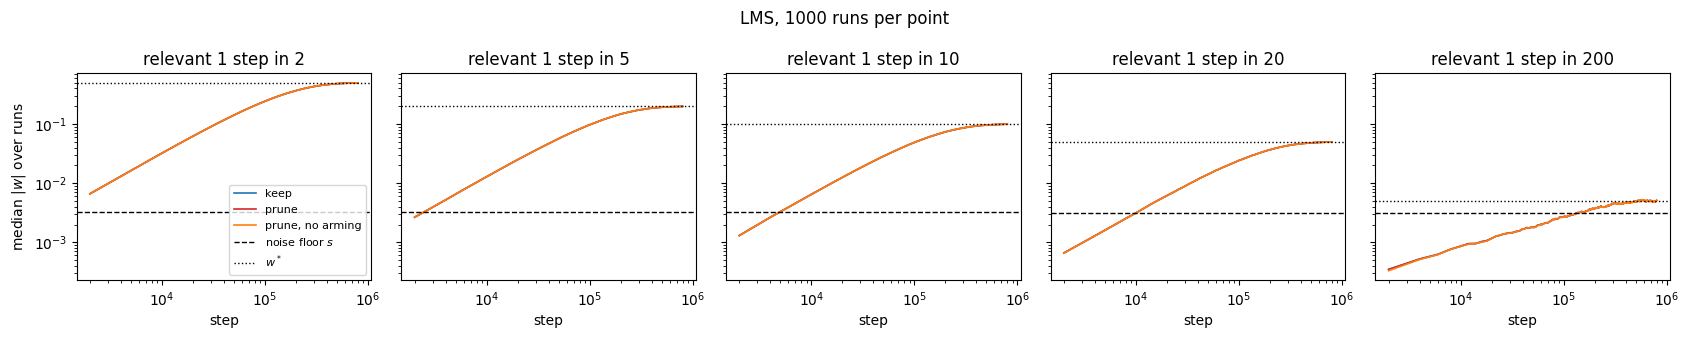

1 in 2  1 in 5  1 in 10  \
keep             median establishment                998.5  2503.0   5001.5   
                 % never established                   0.0     0.0      0.0   
prune            median establishment                998.0  2505.0   5011.0   
                 % never established                   0.0     0.0      0.0   
                 median kills before establishment     0.0     2.0      3.0   
                 median crossings vetoed by arming     0.0     0.0      3.0   
prune, no arming median establishment                999.0  2512.5   5006.5   
                 % never established                   0.0     0.0      0.0   
                 median kills before establishment     0.0     2.0      6.0   

                                                    1 in 20  1 in 200  
keep             median establishment               10735.0  757913.0  
                 % never established                    0.0       0.0  
prune            median establishment               10717.5  758261.5  
                 % never established                    0.0       0.0  
                 median kills before establishment      5.0      13.0  
                 median crossings vetoed by arming      9.0     181.5  
prune, no arming median establishment               10770.0  757578.0  
                 % never established                    0.0       0.0  
                 median kills before establishment     14.0     204.5

In [17]:
arms = jax.tree.map(np.asarray, run_arms(
    floors=[noise_floor(period) for period in RELEVANCE_PERIODS]))

plot_arms(arms, RELEVANCE_PERIODS, PRUNE_STEPS,
          [noise_floor(period) for period in RELEVANCE_PERIODS],
          [optimal_weight(period) for period in RELEVANCE_PERIODS],
          'relevant 1 step in {}', f'LMS, {N_RUNS} runs per point')
prune_summary(arms, RELEVANCE_PERIODS, PRUNE_STEPS)

## 6. Pruning when the feature can be replaced

Section 5 kept one feature forever, so a kill could only ever cost time. The point of pruning is the
opposite: a kill is a chance to draw a *better* feature. Here every kill draws a fresh one from a
pool of two kinds:

- **dead** — never drives the target; useless 100% of the time.
- **sometimes useful** — drives the target one step in 20, exactly the `1 in 20` feature of section 5.

One draw in $D$ is sometimes-useful, and $D$ is what the sweep varies. The relevance period is fixed
at 20 now, so the step-size, the noise floor and $w^\ast$ are identical in every column and the only
thing changing is the quality of the feature supply.

**keep** never prunes, so it is stuck with its opening draw: with probability $1 - 1/D$ that draw is
dead and the run can never establish, no matter how good the learning rule is. Its
`% never established` should land near $100(1 - 1/D)$ — 50, 80, 90, 95, 98% — and that is the number
the pruning arms have to beat.

That statistic needs more care here than in section 5. A dead feature's weight sits exactly one band
from zero, so at any single step it is outside the band 32% of the time — being above the floor when
the run happens to end proves nothing. So a run only counts as established if it cleared the floor
and *stayed* clear for `DRAW_HOLD` steps. The step-size is also chosen to put $w^\ast$ a solid
`DRAW_MARGIN` bands above the floor, so a sometimes-useful feature is unmistakable once learned and
the two kinds of feature cannot be confused.

A kill zeroes $w$ and the optimizer state, de-arms, and redraws the feature type; the squared-error
trace still survives it. Arming finally has something real to protect: a *newly drawn* feature starts
at $w = h = 0$ against a full-size band, so it reads as quiet, and the unarmed rule can throw a good
feature away at its first zero crossing before it has had a chance to show what it is worth.

The three arms no longer share one target stream — the target depends on which feature was drawn, so
the streams diverge as soon as the arms disagree. The feature values, the target noise, which steps
are useful, and the opening draw are still common to all three; the comparison is across `N_RUNS`
runs rather than run by run. The run also has to be long enough to draw a sometimes-useful feature
*and then* establish it, so its length scales with the largest $D$.

In [18]:
RELEVANCE_PERIOD = 20                  # a sometimes-useful feature drives the target 1 step in 20
DRAW_PERIODS = (2, 5, 10, 20, 50)      # one draw in D is sometimes-useful, the rest are dead
DRAW_ARMS = [(draw_period, mode) for draw_period in DRAW_PERIODS for mode in PRUNE_MODES]

DRAW_MARGIN = 5                        # w* in units of the noise floor: a live feature is unmistakable
DRAW_LEARNING_RATE = 2.0 / (DRAW_MARGIN * RELEVANCE_PERIOD) ** 2
DRAW_FLOOR = noise_floor(RELEVANCE_PERIOD, DRAW_LEARNING_RATE)

DRAW_TIMESCALE = 1.0 / (DRAW_LEARNING_RATE * E_X2)      # steps for w to adapt, 1 / (alpha E[x^2])
DRAW_HOLD = int(5 * DRAW_TIMESCALE)    # a run must stay clear of the floor this long to count
DRAW_STEPS = int(8 * max(DRAW_PERIODS) * DRAW_TIMESCALE)

In [19]:
@eqx.filter_jit
def run_draw_arms(seed=BASE_SEED):
    """Section 5's rule and probe, but a kill now redraws the feature instead of keeping it.

    Which kind of feature a run is holding is the one piece of state the rule does not own, so
    `live` rides in the carry beside it."""
    column = lambda values: jnp.array(values)[:, None, None]
    draw_rate = 1.0 / column([draw_period for draw_period, _ in DRAW_ARMS])
    state = PruningProbe.init(column([prune for _, (_, prune, _) in DRAW_ARMS]),
                              column([arm for _, (_, _, arm) in DRAW_ARMS]),
                              step_size=DRAW_LEARNING_RATE)
    shape = (len(DRAW_PERIODS), N_RUNS, 1)
    paired = lambda a: jnp.repeat(a, len(PRUNE_MODES), axis=0)

    def learn_step(carry, _):
        state, live, key, kills, vetoes, established, kills_before, vetoes_before, t = carry
        key, x_key, useful_key, noise_key, draw_key = jax.random.split(key, 5)
        # the stream is common to the three modes; only which feature they hold can differ
        x = paired(jax.random.uniform(x_key, shape, minval=-1.0, maxval=1.0))
        useful = paired(jax.random.uniform(useful_key, shape)) < 1.0 / RELEVANCE_PERIOD
        y = jnp.where(useful & live, x, 0.0) + TARGET_NOISE_STD * paired(
            jax.random.normal(noise_key, shape))

        state, kill, veto, _ = state.step(x, y)
        drawn = jax.random.uniform(draw_key, live.shape) < draw_rate   # a kill draws a new feature
        live = jnp.where(kill, drawn, live)

        t, kills, vetoes = t + 1, kills + kill, vetoes + veto
        below = jnp.abs(state.w) <= DRAW_FLOOR       # establishment = the last step spent below
        latch = lambda before, now: jnp.where(below, now, before)
        return (state, live, key, kills, vetoes, latch(established, t),
                latch(kills_before, kills), latch(vetoes_before, vetoes), t), None

    def chunk(carry, _):                             # one trajectory point per chunk of steps
        carry, _ = jax.lax.scan(learn_step, carry, length=DRAW_STEPS // TRAJECTORY_POINTS, unroll=4)
        return carry, jnp.median(jnp.abs(carry[0].w[..., 0]), axis=1)

    key, draw_key = jax.random.split(jax.random.PRNGKey(seed))
    live = paired(jax.random.uniform(draw_key, shape) < 1.0 / column(DRAW_PERIODS))
    counters = jnp.zeros((len(DRAW_ARMS), N_RUNS, 1), jnp.int32)
    carry, trajectory = jax.lax.scan(
        chunk, (state, live, key, *[counters] * 5, jnp.int32(0)), length=TRAJECTORY_POINTS)
    return dict(established=carry[5], kills_before=carry[6], vetoes_before=carry[7],
                trajectory=trajectory)

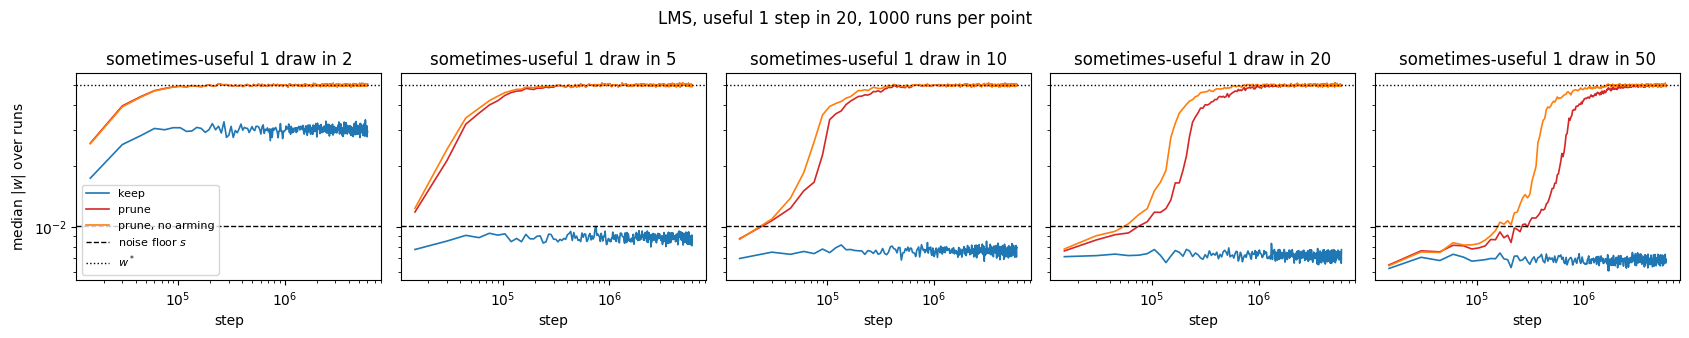

1 in 2     1 in 5  \
keep             median establishment               5600635.5  6000000.0   
                 % never established                     49.0       80.4   
prune            median establishment                 10924.0    59606.5   
                 % never established                      0.2        0.4   
                 median kills before establishment        7.0       11.0   
                 median crossings vetoed by arming       26.0       90.0   
prune, no arming median establishment                 10896.0    46910.5   
                 % never established                      0.2        0.4   
                 median kills before establishment       35.0       90.0   

                                                      1 in 10    1 in 20  \
keep             median establishment               6000000.0  6000000.0   
                 % never established                     90.4       94.2   
prune            median establishment                141463.5   395566.5   
                 % never established                      0.2        0.4   
                 median kills before establishment       15.0       24.0   
                 median crossings vetoed by arming      195.0      523.5   
prune, no arming median establishment                106380.5   215768.5   
                 % never established                      0.2        0.4   
                 median kills before establishment      179.5      333.5   

                                                      1 in 50  
keep             median establishment               6000000.0  
                 % never established                     98.4  
prune            median establishment                905280.5  
                 % never established                      0.2  
                 median kills before establishment       47.0  
                 median crossings vetoed by arming     1717.5  
prune, no arming median establishment                487381.0  
                 % never established                      0.2  
                 median kills before establishment      978.5

In [20]:
draws = jax.tree.map(np.asarray, run_draw_arms())

plot_arms(draws, DRAW_PERIODS, DRAW_STEPS,
          [DRAW_FLOOR] * len(DRAW_PERIODS),
          [optimal_weight(RELEVANCE_PERIOD)] * len(DRAW_PERIODS),
          'sometimes-useful 1 draw in {}',
          f'LMS, useful 1 step in {RELEVANCE_PERIOD}, {N_RUNS} runs per point')
prune_summary(draws, DRAW_PERIODS, DRAW_STEPS, hold=DRAW_HOLD)

## 7. Autostep from a step-size that is far too small

Everything so far ran on a fixed step-size chosen by hand from the relevance period, which is exactly
the knowledge a real learner does not have. The bands are written in terms of $\alpha_i$ though, so
they should follow a step-size that moves: if Autostep starts absurdly low and works its way up, the
bands travel with it and the rule should keep firing in the same places.

That gives a sharp prediction. **The step-size should not change how long a good feature takes to
establish**, provided it is not so large that it destabilises the weight. The correlation between the
feature and the target is a property of the problem, not of $\alpha$, and the threshold the weight is
judged against is rescaled by $\alpha$ along with the jitter it is measuring — so the two should move
together and cancel.

So this is section 5 again — same periods, same run length, same three arms — with
`optax_idbd(autostep=True)` starting from $\alpha_0 = 2^{-20}$, about 40 times smaller than the fixed
step-size section 5 used, and a meta step-size of $2^{-6}$.

Two things have to change for this to mean anything:

- **Establishment is judged against the learner's own band.** There is no fixed analytic floor to
  compare against once $\alpha_i$ moves, so each run is measured against the $s_i$ it builds for
  itself. That is also why the plot no longer draws a floor line.
- **A kill resets the optimizer's state for that feature, not just $h$.** A fresh feature inherits
  nothing: the gradient trace, the learned step-size and Autostep's normaliser all go back to their
  initial values. Only the squared-error trace survives, as before. (`reset_optimizer` in section 5
  already does this — with a fixed step-size the extra resets are no-ops, which is why section 5's
  numbers are unaffected by it.)

Comparing against section 5 takes one more piece of care. Section 5 judged establishment against a
*fixed* analytic floor, and a fixed floor is a far harder target than a moving one: the learner's own
band starts near zero, because the squared-error trace starts at zero, so the weight escapes it
within a handful of steps and the two yardsticks are not comparable. The fixed floor is not available
here anyway. So the table re-runs section 5's LMS judged the same way — against its own band — and it
is the Autostep block that should match it.

In [21]:
AUTOSTEP_INIT_LR = 2.0 ** -20    # deliberately far too small to learn anything on its own
AUTOSTEP_META_LR = 2.0 ** -6

median learned step-size at the end of the run, as log2(alpha):
                  1 in 2  1 in 5  1 in 10  1 in 20  1 in 200
keep               -11.3   -12.4    -13.2    -14.0     -17.0
prune              -11.3   -12.4    -13.2    -14.0     -16.9
prune, no arming   -11.3   -12.4    -13.2    -14.0     -16.9


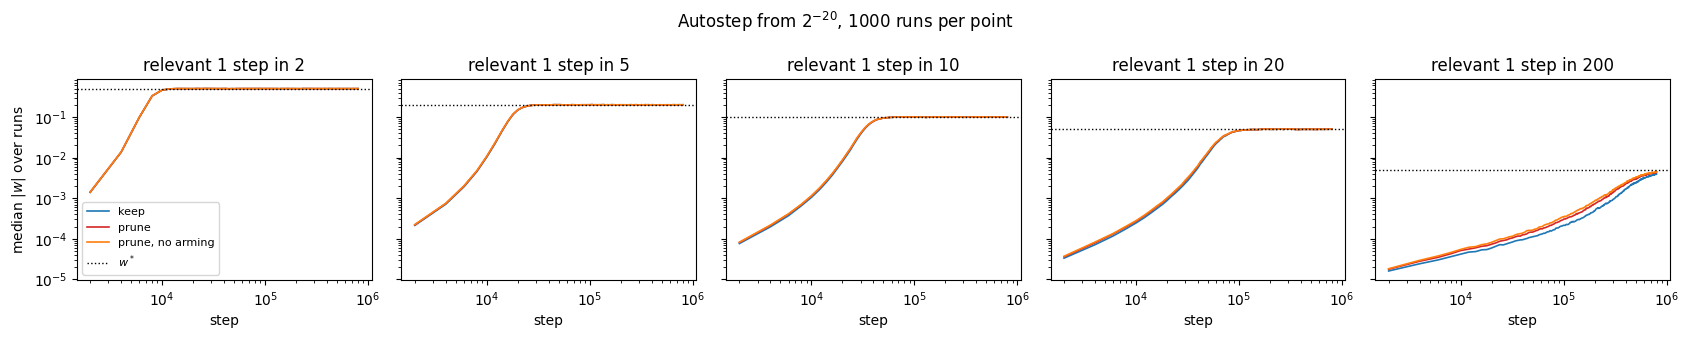

1 in 2  \
Autostep from 2^-20 keep             median establishment                  7.0   
                                     % never established                   0.0   
                    prune            median establishment                  8.0   
                                     % never established                   0.0   
                                     median kills before establishment     0.0   
                                     median crossings vetoed by arming     0.0   
                    prune, no arming median establishment                  7.0   
                                     % never established                   0.0   
                                     median kills before establishment     0.0   
LMS at 2^-15.6      keep             median establishment                  8.0   
                                     % never established                   0.0   
                    prune            median establishment                  8.0   
                                     % never established                   0.0   
                                     median kills before establishment     0.0   
                                     median crossings vetoed by arming     0.0   
                    prune, no arming median establishment                  8.0   
                                     % never established                   0.0   
                                     median kills before establishment     0.0   

                                                                        1 in 5  \
Autostep from 2^-20 keep             median establishment                 58.0   
                                     % never established                   0.0   
                    prune            median establishment                 57.5   
                                     % never established                   0.0   
                                     median kills before establishment     2.0   
                                     median crossings vetoed by arming     0.0   
                    prune, no arming median establishment                 58.0   
                                     % never established                   0.0   
                                     median kills before establishment     2.0   
LMS at 2^-15.6      keep             median establishment                 59.0   
                                     % never established                   0.0   
                    prune            median establishment                 60.0   
                                     % never established                   0.0   
                                     median kills before establishment     2.0   
                                     median crossings vetoed by arming     0.0   
                    prune, no arming median establishment                 61.0   
                                     % never established                   0.0   
                                     median kills before establishment     2.0   

                                                                        1 in 10  \
Autostep from 2^-20 keep             median establishment                 233.5   
                                     % never established                    0.0   
                    prune            median establishment                 239.5   
                                     % never established                    0.0   
                                     median kills before establishment      3.0   
                                     median crossings vetoed by arming      3.0   
                    prune, no arming median establishment                 242.5   
                                     % never established                    0.0   
                                     median kills before establishment      5.0   
LMS at 2^-15.6      keep             median establishment                 243.0   
                                     % ne

In [22]:
autostep = jax.tree.map(np.asarray, run_arms(
    step_size=AUTOSTEP_INIT_LR, meta_lr=AUTOSTEP_META_LR, autostep=True))
lms_own_band = jax.tree.map(np.asarray, run_arms())   # section 5's LMS, judged the same way

learned = np.median(autostep['step_size'], axis=(1, 2))
print('median learned step-size at the end of the run, as log2(alpha):')
print(pd.DataFrame(np.log2(learned).reshape(len(RELEVANCE_PERIODS), len(PRUNE_MODES)).T.round(1),
                   index=[label for label, _, _ in PRUNE_MODES],
                   columns=[f'1 in {period}' for period in RELEVANCE_PERIODS]))

plot_arms(autostep, RELEVANCE_PERIODS, PRUNE_STEPS, None,
          [optimal_weight(period) for period in RELEVANCE_PERIODS],
          'relevant 1 step in {}',
          f'Autostep from $2^{{-20}}$, {N_RUNS} runs per point')
pd.concat({'Autostep from 2^-20': prune_summary(autostep, RELEVANCE_PERIODS, PRUNE_STEPS),
           f'LMS at 2^{np.log2(PRUNE_LEARNING_RATE):.1f}':
               prune_summary(lms_own_band, RELEVANCE_PERIODS, PRUNE_STEPS)})